### Feature–Target Analysis

- Estimate E[target | feature] using binned plots (e.g. qcut)  
- Look for clear structure (monotonic trends or separation), not flat/noisy patterns  
- Check stability across bins (smooth, low variance)  
- Identify features with consistent, interpretable signal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from microstructure_alpha.visualization.eda import conditional_expectation_plotter
from microstructure_alpha.data.loader import load_parquet_glob
from microstructure_alpha.visualization.eda import plot_feature_overview

In [2]:
final_dataset = load_parquet_glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet",
    sort_by="timestamp",
)

Imbalance Check

- Check E[target | imbalance] as a sanity check that features and target are aligned correctly  
- Ensures the dataset and pipeline are built properly before further analysis  

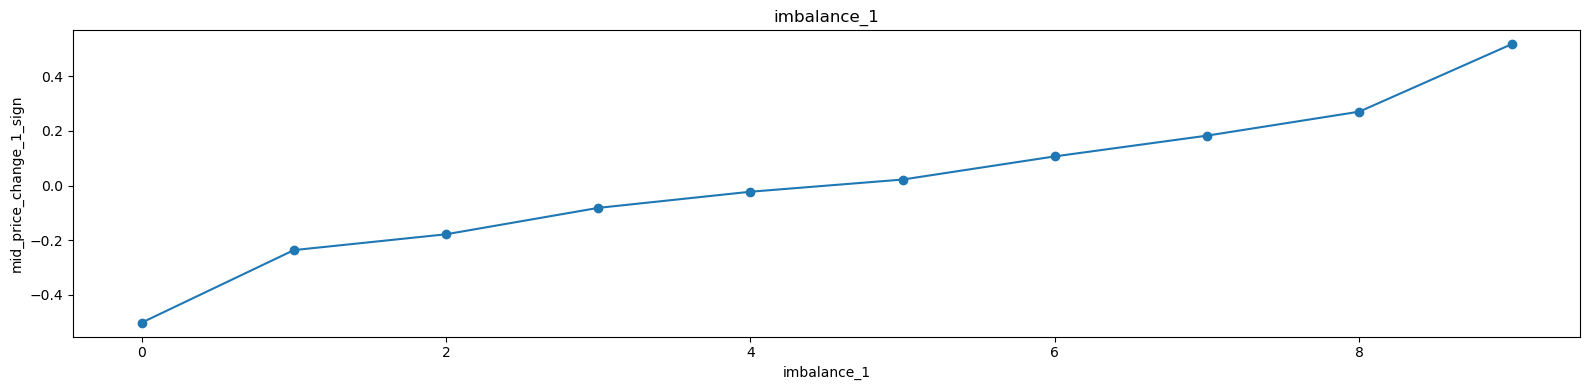

In [3]:
target = "mid_price_change_1_sign"
conditional_expectation_plotter(
    final_dataset, ["imbalance_1"], target, use_uncertainty=False, show=True
)

- Confirms feature and target are correctly aligned
- Imbalance contains predictive signal at short horizons

### Block Bootstrapping

- Time series data is autocorrelated, so use block sampling
- Blocks preserve time dependence and give more realistic uncertainty estimates
- Block size (tau) set based on autocorrelation length of the signal

In [4]:
from microstructure_alpha.utils.stats import compute_signal_autocorr

9.59691179937921 9


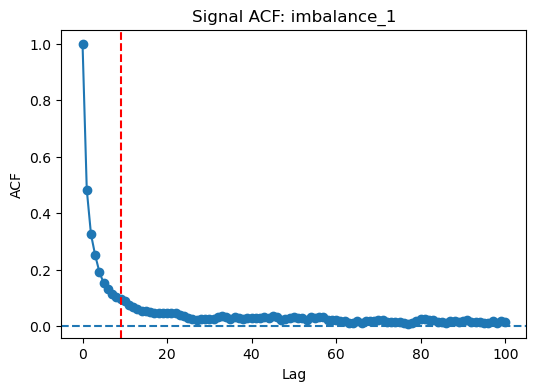

In [5]:
tau_int, tau_cutoff = compute_signal_autocorr(final_dataset, "imbalance_1", target)

print(tau_int, tau_cutoff)

- Autocorrelation decays over ~10–15 steps
- Signals have short memory

### Choosing Block Size

- Use a single block size for consistency
- Choose based on typical autocorrelation across key features

In [6]:
tau_features = [
    "imbalance_1",
    "imbalance_5",
    "imbalance_10",
    "trade_volume_imbalance",
    "mid_minus_micro",
    "microprice_change",
    "log_return_1",
    "mid_price_change_1",
]

In [7]:
list_of_cutoffs = []
for i, col in enumerate(tau_features):
    tau_int, tau_cutoff = compute_signal_autocorr(
        final_dataset, col, target, plot=False
    )
    list_of_cutoffs.append(tau_cutoff)

print(max(list_of_cutoffs))

9


### Conditional Expectations (All Features)

Estimate E[target | feature] for all features to identify which contain predictive signal

In [8]:
from microstructure_alpha.features.feature_lists import ALL_FEATURES

In [9]:
conditional_expectation_plotter(
   final_dataset,
   ALL_FEATURES,
   target,
   block_size=10,
   n_boot=100,
   use_uncertainty=True,
   show=False,
   save_path="C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\notebook_figs\\03_figs\\conditional_plots\\conditional_expectation.pdf",
)


### Feature Scoring

Rank features based on their relationship with the target using:

- signal strength: average absolute response
- signal-to-noise: signal divided by bootstrap uncertainty
- linearity: deviation from linear fit
- stability: signal > noise in each bin
- Used to identify robust features for modelling

In [10]:
from microstructure_alpha.features.feature_diagnostics import feature_scoring

results = []
for feature in ALL_FEATURES:
    res = feature_scoring(final_dataset, feature, target, block_size=10)
    results.append(res)

feature_df = pd.DataFrame(results)
feature_df = feature_df[~feature_df["feature"].str.contains("mid_price_change")]
feature_df = feature_df[feature_df["feature"] != "spread"]

In [11]:
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", "{:.4f}".format)
feature_df = feature_df.sort_values(
    by="s_over_noise_weighted", ascending=False
).reset_index(drop=True)
feature_df.head(10)

,feature,signal_strength,s_over_noise_weighted,nonlinearity,stability
0,imbalance_1,0.2119,21.3558,50.5354,1.0000
1,lob_asks_volume_1,0.2035,21.0812,199.1298,1.0000
2,imbalance_5,0.2114,21.0046,52.2434,1.0000
3,total_ask_volume_10,0.2063,20.4570,236.4583,1.0000
4,imbalance_depth_1,0.2119,20.1730,45.6790,1.0000
5,total_bid_volume_10,0.1986,20.0578,161.8050,1.0000
6,mid_minus_micro,0.2120,19.8013,21.2410,1.0000
7,imbalance_10,0.2089,19.4885,43.0477,1.0000
8,max_bid_ask_vol_ratio,0.2119,19.3610,340.6824,1.0000
9,lob_bids_volume_1,0.1958,18.6048,142.2565,1.0000


Remove raw features then look for correlation between top variables

In [12]:
features = feature_df["feature"].tolist()

features = [f for f in features if not f.startswith("lob_bids_volume_")]
features = [f for f in features if not f.startswith("lob_asks_volume_")]
features = [f for f in features if not f.startswith("lob_bids_price_")]
features = [f for f in features if not f.startswith("lob_asks_price_")]

features = (
    feature_df.set_index("feature")
    .loc[features, "s_over_noise_weighted"]
    .sort_values(ascending=False)
    .index.tolist()
)

data = final_dataset[features]
corr = data.corr(method="spearman")

import seaborn as sns

plt.figure(figsize=(18, 16))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.savefig(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\notebook_figs\\04_eda_figs\\corr_matrix_full_feature.pdf"
)
plt.close()

In [13]:
threshold = 0.8

selected = []
clusters = {}

for f in features:

    for s in selected:
        if abs(corr.loc[f, s]) >= threshold:
            clusters[s].append(f)
            break
    else:
        selected.append(f)
        clusters[f] = []

### Final Feature Set

Features selected based on signal strength, low redundancy, and microstructure reasoning.

- Imbalance
  - imbalance_5
  - imbalance_depth_3
  - imbalance_depth_5

- Price pressure
  - microprice_change
  - microprice_weighted_10

- Trade flow
  - trade_volume_imbalance
  - trade_count_imbalance
  - lag_trade_volume_imbalance_1

- Volatility and activity
  - realized_vol_20
  - liquidity

- Returns and momentum
  - log_return_5
  - momentum_20_log_return_1

- Order book shape
  - lob_depth_ratio_7

- Trade size
  - std_trade_size

### Notes

- Each group captures a different aspect of the market such as supply and demand, flow, and short-term price pressure  
- Highly correlated features were removed  
- Final set keeps interpretable signals with consistent behaviour  

In [14]:
final_feature_list = [
    "imbalance_5",
    "microprice_change",
    "microprice_weighted_10",
    "trade_volume_imbalance",
    "log_return_5",
    "realized_vol_20",
    "liquidity",
    "imbalance_depth_3",
    "imbalance_depth_5",
    "lob_depth_ratio_7",
    "trade_count_imbalance",
    "lag_trade_volume_imbalance_1",
    "std_trade_size",
    "momentum_20_log_return_1",
]

In [15]:
data = final_dataset[selected]
corr = data.corr(method="spearman")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 16))
sns.heatmap(abs(corr), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.savefig(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\notebook_figs\\04_eda_figs\\corr_matrix_final_feature.pdf"
)
plt.close()